# cellAdmix Quickstart: Admixture Correction on Xenium Pancreas

This is the compact version of the recommended cellAdmix workflow:
estimate how much admixture the dataset carries, correct it, and verify
the result. Inputs are the Xenium output bundle (`data/`) and a
cell-type annotation (see the [full
tutorial](pancreas_membrane_scoring_clean.ipynb) for download
instructions and a walkthrough of the intermediate diagnostics; see
[docs/benchmarks.md](../../docs/benchmarks.md) for how the settings
below were chosen).

In [ ]:
annotation <- read.csv(file.path("annotations", "annotation.csv.gz"))
cell_annotation <- setNames(annotation$merged_annotation, annotation$cell_id)

ds <- cellAdmix("data", output_dir = "out", annotation = cell_annotation)
fit <- ds$fit(nmf_variant = "invsqrt_kl")

Reusing cached run fit_manual_rank9_invsqrt_kl (parameters match)

For membrane-stained data, membrane scoring with the `invsqrt_kl`
factorization removes the most admixture in our benchmarks; on data
without stains, use `fit$score_bridge()` with the default `ls_nmf`
factorization instead.

## How much admixture is there?

The audit estimates, for every ordered cell-type pair, the admixture
rate — what share of the target type’s molecules leaked in from the
source — using only the spatial exposure structure, before any
correction:

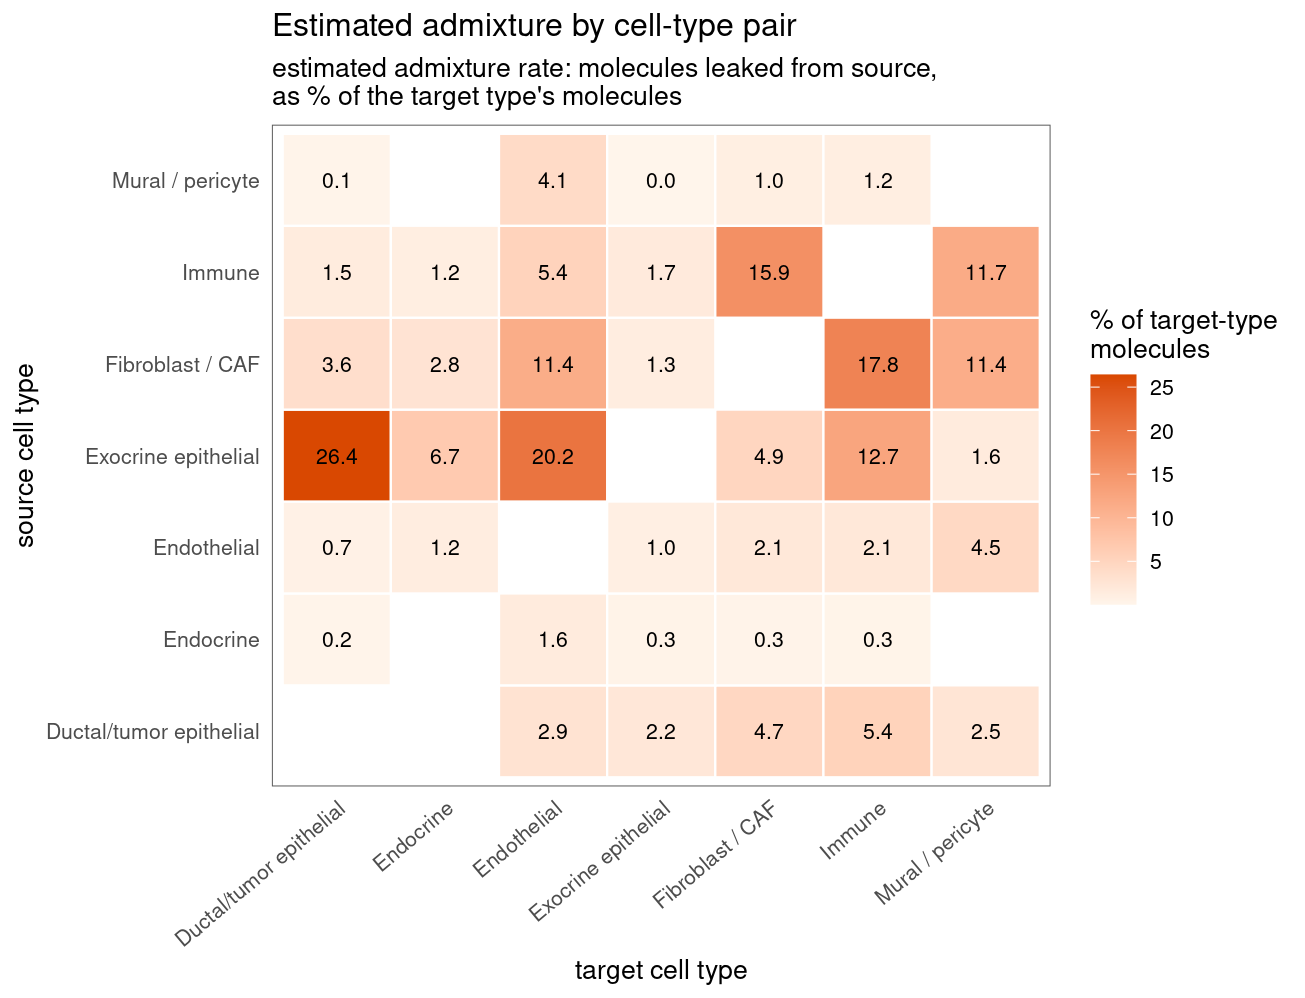

In [ ]:
audit <- fit$audit_admixture()
audit$plot_map()

## Correct

One quick check that the factorization is sound — most factors should
sit above the 0.3 stability threshold:

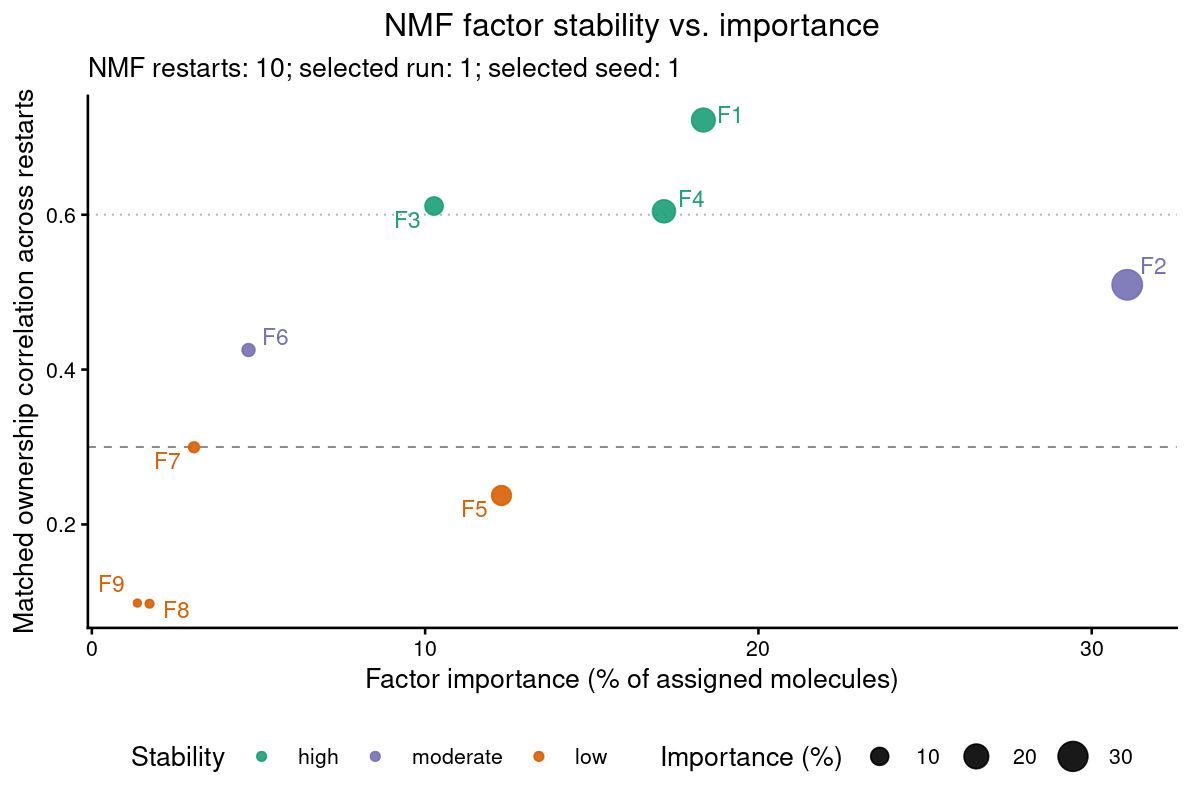

In [ ]:
fit$plot_stability()

Scoring turns factors into removal rules, and correction removes the
matching molecules by a vote across the fit’s NMF restarts: each restart
is scored and vetted independently (including the native-factor
false-positive check), and a molecule is removed when at least 30% of
the restarts remove it. The vote stabilizes the seed-dependence of
single-fit corrections and outperforms every individual restart in our
benchmarks:

In [ ]:
score <- fit$score_membrane()
correction <- score$correct(rules = score$rules())

Ensemble correction over 10 members: molecules removed by >= 3 members (vote >= 0.30) are dropped (1,595,516 molecules).

## Verify

The audit re-measures the same exposure gradients on the corrected
counts. The report gives per-pair cleanup sensitivity, the own-marker
false-removal rate (how much almost-surely-genuine expression was lost),
and warns about any detected pair the rules did not cover:

Immune, but no removal rule covers this pair

Endothelial, but no removal rule covers this pair

but no removal rule covers this pair

pericyte, but no removal rule covers this pair

but no removal rule covers this pair

Endothelial, but no removal rule covers this pair

Fibroblast / CAF, but no removal rule covers this pair

but no removal rule covers this pair

$detected_pairs
[1] 39

$estimated_admixed_molecules
[1] 1454078

$leakage_removed_overall
[1] 0.5824762

$median_pair_sensitivity
[1] 0.9923732

$own_marker_false_removal
[1] 0.03254766

$worst_false_removal
[1] "Exocrine epithelial"

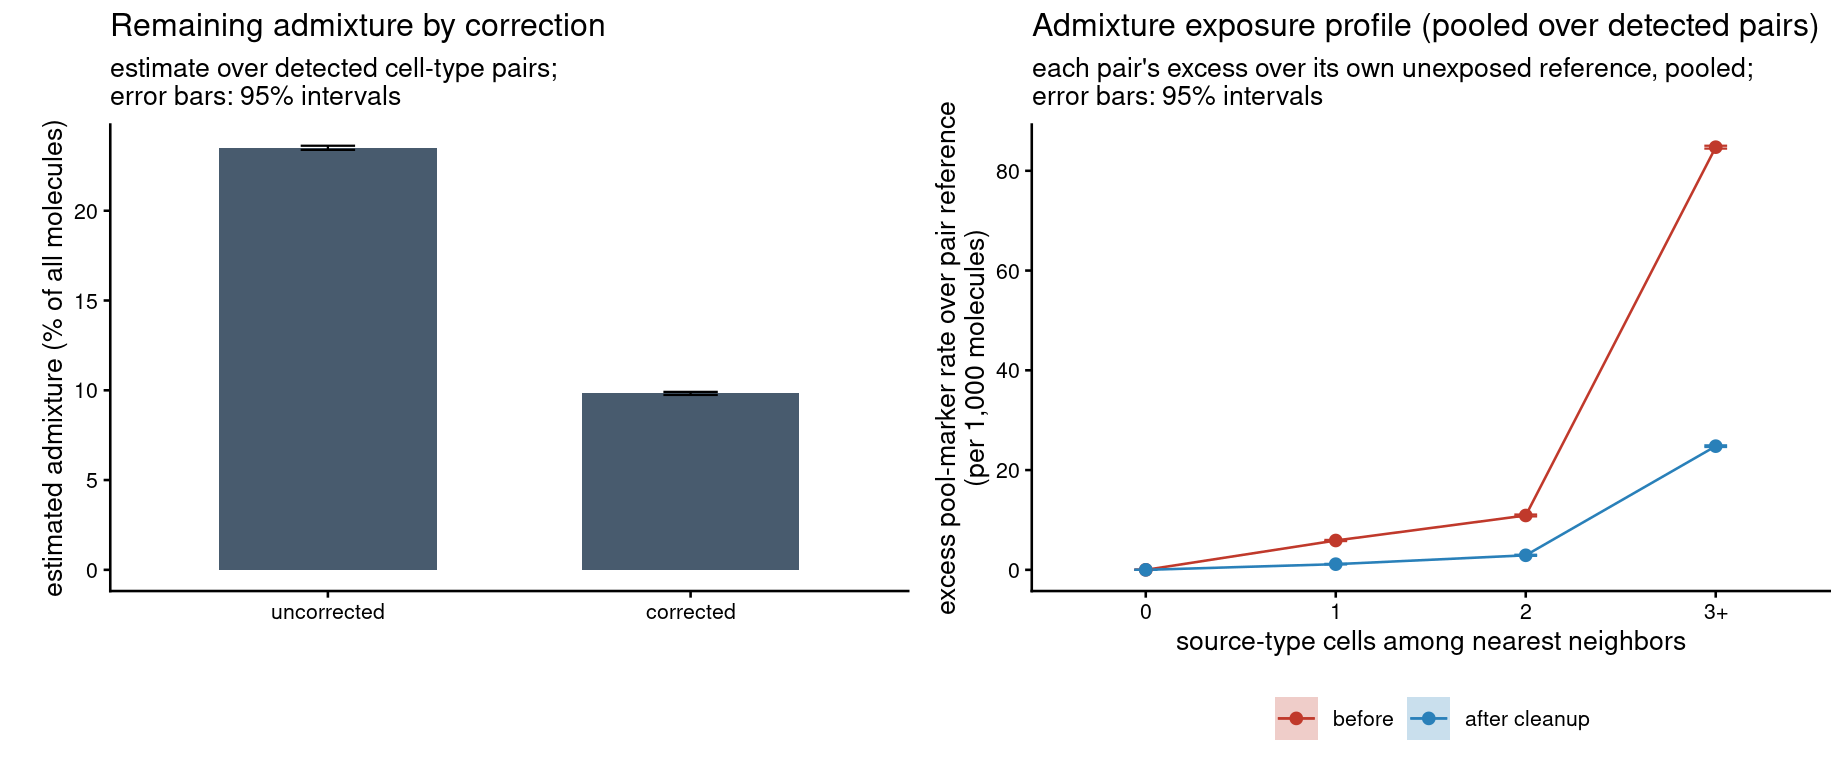

In [ ]:
report <- audit$evaluate(correction)

## Use the corrected counts

In [ ]:
corrected_counts <- correction$counts()
dim(corrected_counts)

[1]    377 140335

`corrected_counts` is a sparse genes × cells matrix ready for downstream
analysis; `celladmix_add_to_seurat()` and the SpatialData helpers attach
it to existing objects.